### Understand the problem

### Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.xkcd()
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split


In [2]:
dataset_train=pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')
dataset_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
dataset_test=pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")
dataset_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


### Data Exploration

In [4]:
dataset_train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [5]:
dataset_test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [6]:
df_train=dataset_train.fillna(method="ffill")

In [7]:
df_test=dataset_test.fillna(method="ffill")

In [8]:
df_train.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

In [9]:
df_test.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
dtype: int64

In [10]:
for i in df_train:
    print(i,":",len(df_train[i].unique()))#unique values of all columns

PassengerId : 8693
HomePlanet : 3
CryoSleep : 2
Cabin : 6560
Destination : 3
Age : 80
VIP : 2
RoomService : 1273
FoodCourt : 1507
ShoppingMall : 1115
Spa : 1327
VRDeck : 1306
Name : 8473
Transported : 2


In [11]:
for i in df_test:
    print(i,":",len(df_test[i].unique()))#unique values of test data

PassengerId : 4277
HomePlanet : 3
CryoSleep : 2
Cabin : 3265
Destination : 3
Age : 79
VIP : 2
RoomService : 842
FoodCourt : 902
ShoppingMall : 715
Spa : 833
VRDeck : 796
Name : 4176


In [12]:
df_train.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8693 non-null   object 
 2   CryoSleep     8693 non-null   bool   
 3   Cabin         8693 non-null   object 
 4   Destination   8693 non-null   object 
 5   Age           8693 non-null   float64
 6   VIP           8693 non-null   bool   
 7   RoomService   8693 non-null   float64
 8   FoodCourt     8693 non-null   float64
 9   ShoppingMall  8693 non-null   float64
 10  Spa           8693 non-null   float64
 11  VRDeck        8693 non-null   float64
 12  Name          8693 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(3), float64(6), object(5)
memory usage: 772.6+ KB


In [14]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4277 non-null   object 
 2   CryoSleep     4277 non-null   bool   
 3   Cabin         4277 non-null   object 
 4   Destination   4277 non-null   object 
 5   Age           4277 non-null   float64
 6   VIP           4277 non-null   bool   
 7   RoomService   4277 non-null   float64
 8   FoodCourt     4277 non-null   float64
 9   ShoppingMall  4277 non-null   float64
 10  Spa           4277 non-null   float64
 11  VRDeck        4277 non-null   float64
 12  Name          4277 non-null   object 
dtypes: bool(2), float64(6), object(5)
memory usage: 376.0+ KB


### Label Encoding

In [15]:
from sklearn import preprocessing
label_encoder=preprocessing.LabelEncoder()

columns = df_train[[ 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination','VIP','Name','Transported']]  # columns names where transform is required
for X in columns:
  exec(f'le_{X} = preprocessing.LabelEncoder()')  #create label encoder with name "le_X", where X is column name
  exec(f'df_train.{X} = le_{X}.fit_transform(df_train.{X})')  #execute fit transform for column X with respective lable encoder "le_X", where X is column name
df_train.head() 

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,1,0,149,2,39.0,0,0.0,0.0,0.0,0.0,0.0,5252,0
1,0002_01,0,0,2184,2,24.0,0,109.0,9.0,25.0,549.0,44.0,4502,1
2,0003_01,1,0,1,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,457,0
3,0003_02,1,0,1,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,7149,0
4,0004_01,0,0,2186,2,16.0,0,303.0,70.0,151.0,565.0,2.0,8319,1


In [16]:
df_train.shape

(8693, 14)

In [17]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8693 non-null   int64  
 2   CryoSleep     8693 non-null   int64  
 3   Cabin         8693 non-null   int64  
 4   Destination   8693 non-null   int64  
 5   Age           8693 non-null   float64
 6   VIP           8693 non-null   int64  
 7   RoomService   8693 non-null   float64
 8   FoodCourt     8693 non-null   float64
 9   ShoppingMall  8693 non-null   float64
 10  Spa           8693 non-null   float64
 11  VRDeck        8693 non-null   float64
 12  Name          8693 non-null   int64  
 13  Transported   8693 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 950.9+ KB


In [18]:
from sklearn import preprocessing
columns = df_test[[ 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination','VIP','Name']]  # columns names where transform is required
for X in columns:
  exec(f'le_{X} = preprocessing.LabelEncoder()')  #create label encoder with name "le_X", where X is column name
  exec(f'df_test.{X} = le_{X}.fit_transform(df_test.{X})')  #execute fit transform for column X with respective lable encoder "le_X", where X is column name
df_train.head() 

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,1,0,149,2,39.0,0,0.0,0.0,0.0,0.0,0.0,5252,0
1,0002_01,0,0,2184,2,24.0,0,109.0,9.0,25.0,549.0,44.0,4502,1
2,0003_01,1,0,1,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,457,0
3,0003_02,1,0,1,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,7149,0
4,0004_01,0,0,2186,2,16.0,0,303.0,70.0,151.0,565.0,2.0,8319,1


In [19]:
df_test.shape

(4277, 13)

In [20]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4277 non-null   int64  
 2   CryoSleep     4277 non-null   int64  
 3   Cabin         4277 non-null   int64  
 4   Destination   4277 non-null   int64  
 5   Age           4277 non-null   float64
 6   VIP           4277 non-null   int64  
 7   RoomService   4277 non-null   float64
 8   FoodCourt     4277 non-null   float64
 9   ShoppingMall  4277 non-null   float64
 10  Spa           4277 non-null   float64
 11  VRDeck        4277 non-null   float64
 12  Name          4277 non-null   int64  
dtypes: float64(6), int64(6), object(1)
memory usage: 434.5+ KB


### Exploratory Data Analysis

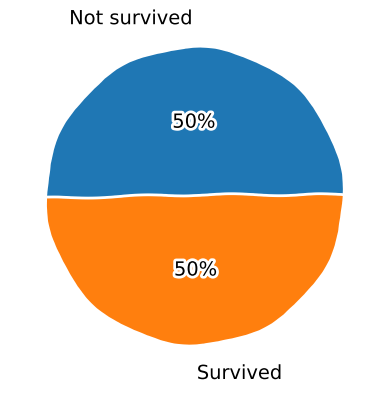

In [21]:
a = df_train['Transported'].value_counts()
labels = ['Not survived', 'Survived']

plt.pie(a,
        labels=labels, 
        autopct='%1.0f%%', #autopct is used for display percentage of value
        pctdistance=0.5, #pctdistance is used for set distance of percentage from center
        labeldistance=1.2) #labeldistance is used for set distance of label from center


plt.show() 


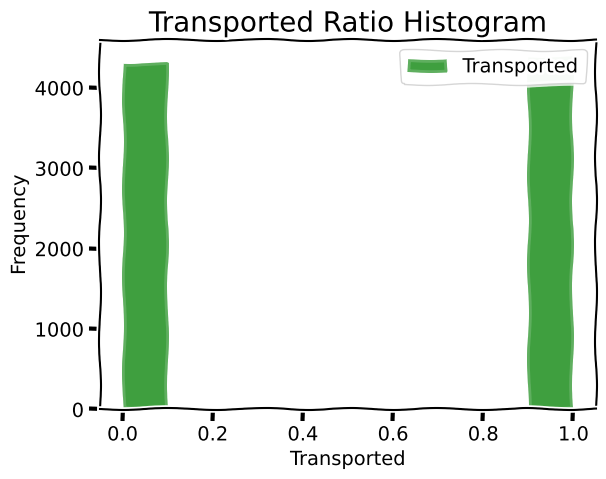

In [22]:
#set figure
f, ax = plt.subplots(1,1)

#graph histogram
plt.hist(df_train['Transported'],  alpha=0.5, color='g', label='Transported')

#set legend
plt.legend(loc='upper right')

# #set title & axis titles
ax.set_title('Transported Ratio Histogram', fontsize=20)
ax.set_xlabel('Transported')
ax.set_ylabel('Frequency')

#set limit
# plt.ylim(0, )

plt.show()

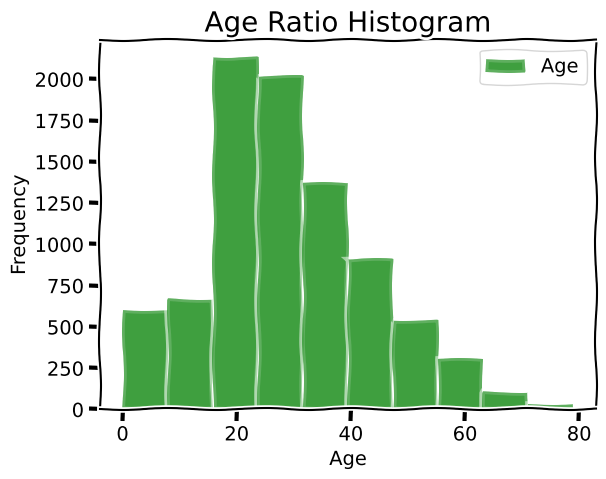

In [23]:
#set figure
f, ax = plt.subplots(1,1)

#graph histogram
plt.hist(df_train['Age'],  alpha=0.5, color='g', label='Age')

#set legend
plt.legend(loc='upper right')

# #set title & axis titles
ax.set_title('Age Ratio Histogram', fontsize=20)
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')

#set limit
# plt.ylim(0, )

plt.show()

<AxesSubplot:xlabel='Transported', ylabel='Age'>

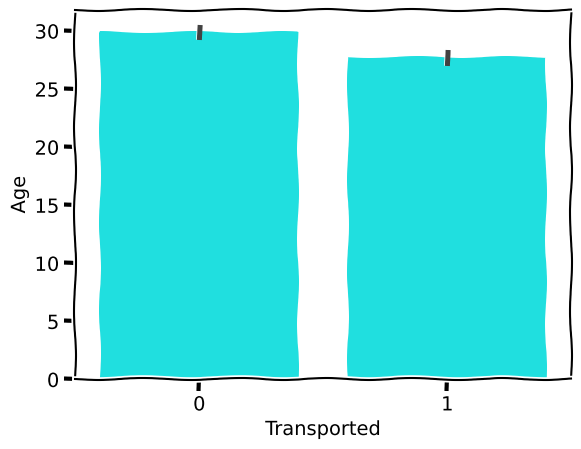

In [24]:
sns.barplot(x='Transported',y='Age',data=df_train,color='cyan',lw=4,ls='solid')

<AxesSubplot:xlabel='Transported', ylabel='Age'>

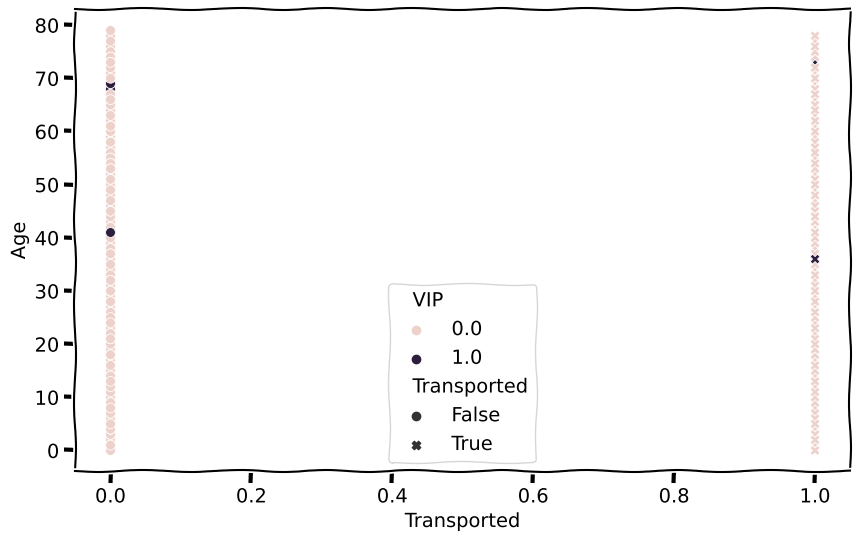

In [25]:
plt.figure(figsize=(10,6))#que
sns.scatterplot(x="Transported",
                y="Age",
                hue="VIP",
                style="Transported", #style of marker
                data=dataset_train,
                s=50)  #s = size of marker

### Split the data

In [26]:
x=df_train[['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck','Name']]
y=df_train[['Transported']]

In [27]:
x

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001_01,1,0,149,2,39.0,0,0.0,0.0,0.0,0.0,0.0,5252
1,0002_01,0,0,2184,2,24.0,0,109.0,9.0,25.0,549.0,44.0,4502
2,0003_01,1,0,1,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,457
3,0003_02,1,0,1,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,7149
4,0004_01,0,0,2186,2,16.0,0,303.0,70.0,151.0,565.0,2.0,8319
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,1,0,146,0,41.0,1,0.0,6819.0,0.0,1643.0,74.0,3524
8689,9278_01,0,1,5280,1,18.0,0,0.0,0.0,0.0,0.0,0.0,4780
8690,9279_01,0,0,5285,2,26.0,0,0.0,0.0,1872.0,1.0,0.0,3002
8691,9280_01,1,0,2131,0,32.0,0,0.0,1049.0,0.0,353.0,3235.0,1596


In [28]:
y

,Transported
0,0
1,1
2,0
3,0
4,1
...,...
8688,0
8689,0
8690,1
8691,0


In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=30,random_state=50)

In [30]:
# Import the AdaBoost classifier
from sklearn.ensemble import AdaBoostClassifier


# Create adaboost classifer object
abc = AdaBoostClassifier(n_estimators=50, learning_rate=0.1, random_state=50)

# Train Adaboost Classifer
model1 = abc.fit(x_train, y_train)


#Predict the response for test dataset
pred = model1.predict(x_test)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [31]:
model1.score(x_test,y_test)*100#accuracy

76.66666666666667

In [32]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
error = mean_absolute_error(pred,y_test)*100
error#error

23.333333333333332

In [33]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,pred)
cm

array([[13,  4],
       [ 3, 10]])

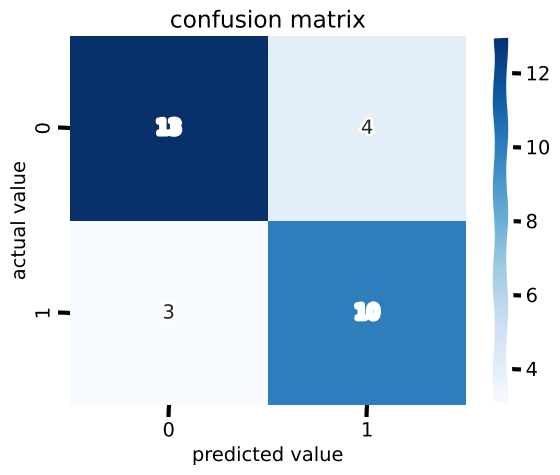

In [34]:
#visulization of confusion matrix
ax=sns.heatmap(cm,annot=True,cmap='Blues')
ax.set_title("confusion matrix")
ax.set_xlabel("predicted value")
ax.set_ylabel("actual value")
plt.show()

In [35]:
sample_submission=model1.predict(df_test)
sample_submission

array([1, 0, 1, ..., 1, 1, 1])

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# assuming that sample_submission is an array of labels that need to be encoded
le.fit_transform(sample_submission)

# now the encoder is fitted and we can use inverse_transform method
labels = le.inverse_transform(sample_submission)
print(labels)




[1 0 1 ... 1 1 1]


In [37]:
test2=df_test["PassengerId"]
test2

0       0013_01
1       0018_01
2       0019_01
3       0021_01
4       0023_01
         ...   
4272    9266_02
4273    9269_01
4274    9271_01
4275    9273_01
4276    9277_01
Name: PassengerId, Length: 4277, dtype: object

In [38]:
fl = pd.DataFrame({
    "PassengerId":test2.values,
    "Transported" : sample_submission
},columns=["PassengerId","Transported"])
fl

,PassengerId,Transported
0,0013_01,1
1,0018_01,0
2,0019_01,1
3,0021_01,1
4,0023_01,0
...,...,...
4272,9266_02,1
4273,9269_01,0
4274,9271_01,1
4275,9273_01,1


In [39]:
fl.set_index("PassengerId", inplace=True)
fl.to_csv("sample_submission.csv")

In [40]:
pd.read_csv("sample_submission.csv")

,PassengerId,Transported
0,0013_01,1
1,0018_01,0
2,0019_01,1
3,0021_01,1
4,0023_01,0
...,...,...
4272,9266_02,1
4273,9269_01,0
4274,9271_01,1
4275,9273_01,1
